In [94]:
import seaborn as sns
from sklearn.datasets import load_iris, make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import matplotlib.pyplot as plt

scaler = StandardScaler()

In [29]:
iris = load_iris()
df = load_iris(as_frame=True).frame

X = iris.data
y = iris.target

In [8]:
X_scaled = scaler.fit_transform(X)

<Axes: >

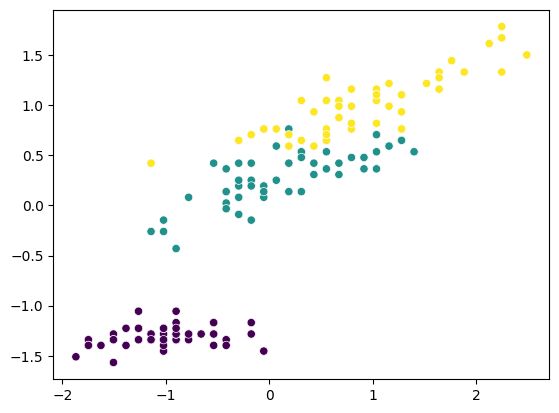

In [16]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=y)

In [17]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

<Axes: >

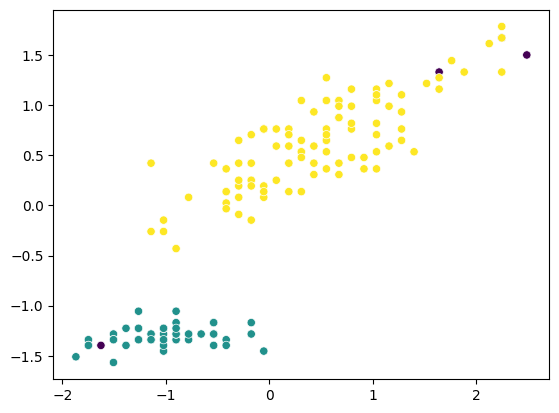

In [24]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=labels)

In [37]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [35]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [40]:

# Add labels to your dataframe
df['cluster'] = labels

# Convert to string so plotly treats it as categorical, not continuous
df['cluster'] = df['cluster'].astype(str)

fig = px.scatter_3d(
    df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    z='petal length (cm)',
    color='cluster',              # color by cluster label instead of petal width
    symbol='target',              # keep true labels as marker shape for comparison
    title="3D Cluster Plot (colored by predicted labels)",
    color_discrete_map={          # optional: force noise points to a specific color
        '-1': 'red',
        '0': '#1f77b4',
        '1': '#ff7f0e'
    }
)
fig.update_traces(marker=dict(size=4))
fig.show()

## Non-Linear dataset

(-1.2935963192244948, 2.3234463193044, -0.6711248887717242, 1.2201762673946694)

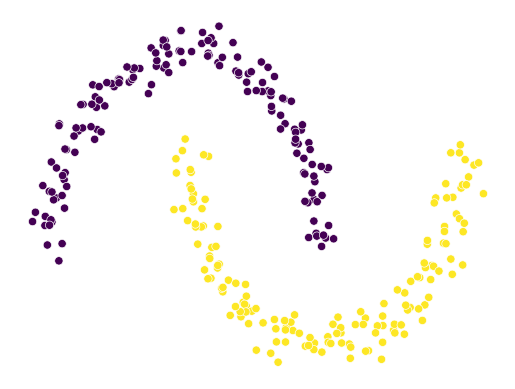

In [88]:
X, y = make_moons(n_samples=300,
                  noise=0.06,
                  random_state=42)

sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y)
plt.axis(False)

In [89]:
X_scaled = scaler.fit_transform(X)

<Axes: >

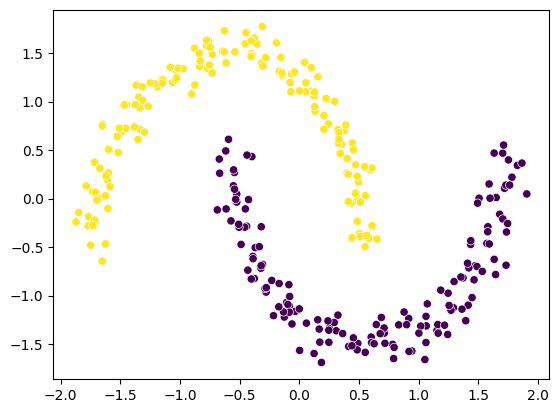

In [95]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=labels)

<Axes: >

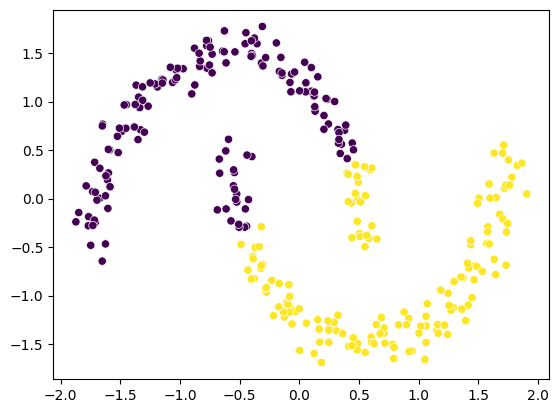

In [96]:
k_means = KMeans(n_clusters=2)

labels = k_means.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=labels)